
---

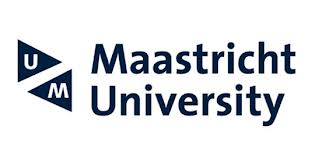

# Faculty of Science and Engineering - Department of Advanced Computer Sciences
# Course Advanced Natural Language Processing - Tutorial Tokenization

⏱️ **Estimated time:** 1.6 hours – 3.5 hours


# Faculty of Science and Engineering - Department of Advanced Computer Sciences
# Course Advanced Natural Language Processing (KEN4259) - Tutorial on Speech Recognition
By: Gijs Wijngaard

---

Version 2026-2027

---

Welcome to this tutorial on Speech Recognition. In this notebook, you will learn how to recognize and classify speech. We start with audio signal representations (waveforms, spectrograms, mel spectrograms) and then build keyword classification models — first from scratch using a CNN, then using a pretrained Whisper model. We also explore the impact of noise on speech recognition performance.

The notebook uses PyTorch and TorchAudio for deep learning on audio data.

⏱️ **Estimated time:** 1.8 hours – 3.8 hours

## Learning Goals

After completing this tutorial, you will be able to:

- **Understand** how speech signals are represented digitally (sampling rate, waveforms).
- **Compute** spectrograms from audio using the Short-Time Fourier Transform (STFT).
- **Explain** the mel scale and why mel spectrograms are better suited for speech processing than linear spectrograms.
- **Build** a CNN-based keyword classification model using PyTorch.
- **Train and evaluate** speech classification models, computing accuracy and F1 scores.
- **Apply** pretrained models (Whisper) for audio classification via transfer learning.
- **Analyze** the impact of noise on speech recognition performance and understand data augmentation techniques.

In this notebook, we will use PyTorch. Using this, we need less code to build the neural networks, while also still achieving high results. We also use TorchAudio, which is PyTorch' audio deep learning framework. This framework helps us deal with audio datasets in PyTorch.

The first step is to **enable GPU**. A GPU is a Graphical Processing Unit, capable of calculating vectors and matrices much faster than CPU units, like the one in your laptop. Since neural networks are basically made out of matrices, we gain serious speed improvements by using GPU's.

We enable the GPU by clicking on *Runtime* in the menu above, then click *Change runtime type*. Make sure the Runtime type is set to *Python 3* and under *Hardware accelerator* click *T4 GPU*. Then press *Save*. If the following code returns *True*, you know that you are using the GPU currently.

In [ ]:
import torch
torch.cuda.is_available()

With the command `!nvidia-smi` we can show how fast our GPU is. We see how many GPU's we have, we see which type of GPU we have and we see how much memory it has.

In [ ]:
!nvidia-smi

## Dataset ML Spoken Words
We now download Multilingual Spoken Words Corpus. This dataset has over 6000 hours of 16kHz English speech, divided in 340,000 keywords. The data is crowd-sourced, and force alignment is applied to it.
HuggingFace supports downloading the dataset for us. See more information about the dataset [here](https://huggingface.co/datasets/MLCommons/ml_spoken_words). We use two datasets, one for training and one for testing. This test set is to validate our model to see if the model has no sampling bias. To evaluate our model correctly, we should **never train on our test set!**.
Let's first download the datasets pip package, import datasets and download the data

In [ ]:
import importlib, subprocess, sys
if importlib.util.find_spec('datasets') is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "datasets"])
import datasets


For this tutorial, we are going to focus on 1 language first, Dutch! Since there are not that many Dutch samples available in the dataset in comparison to other languages such as German or English, we can download this data more easily.

We pass "nl" as an argument to the datasets function to import the data. In this way, we don't download all the data, but only a small part of it. The following function may take about 10 minutes.

In [ ]:
train_data, validation_data = datasets.load_dataset("MLCommons/ml_spoken_words", languages=["nl"], split=["train", "validation"])

Let's filter it down so we have about the same female as male speakers in the dataset. This is to combat overfitting.

In [ ]:
train_data

Our dataset contains 7 features, 2 of which are important to us for this tutorial. Lets inspect a single data of the dataset:

In [ ]:
train_data[0]

The wav file is already imported to us as an array. We can access the data by accessing the `["audio"]["array"]` index: We can listen this audio by using `IPython`.

In [ ]:
import IPython
IPython.display.Audio(train_data[0]["audio"]["array"], rate=train_data[0]["audio"]["sampling_rate"])

We can plot the data with `matplotlib`:

In [ ]:
import matplotlib.pyplot as plt
plt.plot(train_data[0]["audio"]["array"])

As explained in the lecture, waveforms on the computer are stored as discrete representations. Normally, sounds have a contunious representation. The sample rate is how many values we have in these discrete representations per second. Thus, we can calculate the length of the audio in seconds by using the sample rate.

In [ ]:
len(train_data[0]["audio"]["array"]) / train_data[0]["audio"]["sampling_rate"]

We see that the first item of our dataset is exactly 1 second long (as is most of the other data in our dataset).


 We are going to use PyTorch in this tutorial, to be able to import the data easily in PyTorch, we are going to format the dataset to Tensors first:

In [ ]:
train_data = train_data.with_format("torch")
validation_data = validation_data.with_format("torch")

In [ ]:
train_data[0]

Now, we are going to convert the raw audio to a representation that a machine learning model can handle. The raw audio only contains time and amplitude, thus we need to apply fourier transforms on the data to get frequency, then we stack those to get a representation of mel filterbanks.

In [ ]:
stft = torch.stft(train_data[0]["audio"]["array"], n_fft=400, win_length=200, onesided=True, return_complex=True)
# First dimension is frequency, second dimension is time
stft.shape

We can calculate a spectrogram by squaring the magnitude of a short-time forier transform. Since we are dealing with complex values, we need to do `abs()` first. We get an "real-valued power spectrogram"

In [ ]:
spectrogram = stft.abs() ** 2
plt.pcolormesh(spectrogram)

This is already a nice spectrogram! We can already clearly distinct two areas, one on the lower end of the frequency, one a bit higher. In this plot, each value of the frequency represents a specific range of Hz. We calculate this by `n * sample_rate / N` where `N = n_fft`. Thus, the first bin is `0 * 16000 / 400 = 0` until `1 * 16000 / 400 = 40`, the second bin is from that until `2 * 16000 / 400 = 80`. We end up with 201 bins, up until a sample rate of 8000, half the nyqvist frequency.

We see that the frequency doesn't go that high. This is because the voiced speech of a typical adult male has a frequency from 85 to 155 Hz, and that of a typical adult female from 165 to 255 Hz.

Now, we can augment the spectrograms to be better in line with our hearing. We need two things for this:
- Mel scale: researchers have found that a different scale would be better suited for plotting spectrograms, instead of linear we have one where with each step we increase the difference
- Logarithm. By using a logaritmic scale we limit the numerical range, the result is a more closer range to what we humans hear.

Now let's compute the mel scale. We can do this by getting the filter banks from torchaudio.

In [ ]:
import torchaudio
mel_banks = torchaudio.functional.melscale_fbanks(
    spectrogram.shape[0],
    n_mels=80,
    f_min=0.0,
    f_max=16000 / 2.0,
    sample_rate=16000)

We can plot these filter banks. As you can see below, each filter bank represents a different part of the spectrum. The smaller mel banks have a smaller width, thus represent only a few frequencies. In essence: we store more information of the lower Hz values, than the larger Hz values.

In [ ]:
plt.figure(figsize=[16,9])
plt.plot(mel_banks)
plt.show()

We now only need a simple matrix multiplication to get to a melspectrogram!

In [ ]:
melspectrogram = mel_banks.T @ spectrogram
plt.pcolormesh(melspectrogram)

Lastly, we calculate the log of a mel spectrogram, to limit the numerical range. We add a really small value to the mel spectrogram first, since some values of the `melspectrogram` may be 0, and the log of 0 is undefined.

In [ ]:
logmelspectrogram = (melspectrogram + 1e-10).log()
plt.pcolormesh(logmelspectrogram)

We could also just have used torchaudio.melspectrogram, instead of all these steps above. See this figure: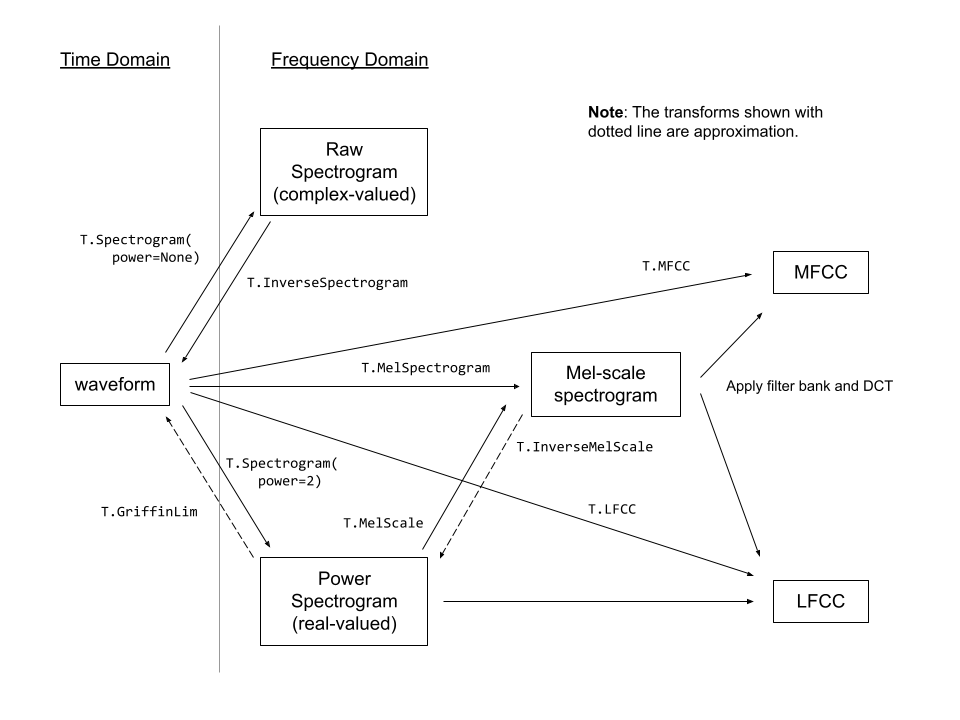

We went waveform to real-valued power spectrogram (below in the figure) to mel-scale spectrogram. We did this to make sure you understand all the steps As you can see, we can directly apply T.melspectrogram as well. We then do 2 steps in 1.

In [ ]:
mel_transform = torchaudio.transforms.MelSpectrogram(sample_rate=16_000,
                                            n_mels = 80,
                                            n_fft = 200,
                                            f_min=0.0,
                                            f_max=16_000 / 2.0)
direct_mels = mel_transform(train_data[0]["audio"]["array"]).log()
plt.pcolormesh(direct_mels)

## Wake Word Detection
Let's now filter our dataset to work with 10 labels. The 10 most occuring words for our simple word classifiaction algorithm.

In [ ]:
import pandas as pd
most_occurring = pd.Series(train_data["keyword"]).value_counts()[:10]
most_occurring

We only take the data rows that have these keywords in them:

In [ ]:
train_data = train_data.filter(lambda x: x["keyword"] in most_occurring.keys(), num_proc=2)
validation_data = validation_data.filter(lambda x: x["keyword"] in most_occurring.keys(), num_proc=2)

We define a function to map the label to each id.

In [ ]:
label2id = {v:k for (k,v) in enumerate(most_occurring.keys())}
label2id

Now let's create a simple CNN network that we are going to train on the data. We can use this because all our data is 1 second long, so we don't need to use something recurrent as RNN's or Transformers. Lets create one with two conv layers and 2 pool layers, with relu's inbetween. The classification head will have an output of 10, since we have 10 classes we are going to predict on.

In [ ]:
from torch import nn
class SimpleCNN(nn.Module):
    def __init__(self, num_outputs=10):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1)
        self.fc1 = nn.Linear(32 * 20 * 40, 128) # Input dimensions are the shape of the previous layer
        self.fc2 = nn.Linear(128, num_outputs)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 32 * 20 * 40) # First dimension is batch size
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

Let's shuffle the data and define the model and auxillary functions.

In [ ]:
train_data = train_data.shuffle(seed=42)
validation_data = validation_data.shuffle(seed=42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleCNN(num_outputs=10).to(device) # The number of outputs is equal to the number of labels in the dataset
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-04)

### Training a Model

Now that we went over the basics of how audio works, we can go to how we could train this model. Let's take everything step by step!
We first create a PyTorch Dataset function. Upon retrieval of item of this Dataset, we return the processed audio and the label feature:

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchaudio.transforms import MelSpectrogram
from torch.nn import functional as F
import torchaudio
import numpy as np


class AudioDataset(Dataset):
    def __init__(self, data, label2id={0: 0, 1: 1}, label="keyword"):
        self.data = data
        self.label2id = label2id
        self.label = label
        self.mel_transform = MelSpectrogram(sample_rate=16_000, n_mels=80, n_fft=200, f_min=0.0, f_max=16_000/2.0)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        label = self.data[idx][self.label]
        if torch.is_tensor(label):
            label = label.item()
        label = torch.tensor(self.label2id[label])
        mel_spectrogram = self.get_mel(self.data[idx]["audio"]["array"])
        return mel_spectrogram, label


    def get_mel(self, audio):
        audio = self.change_length(audio) # Make sure all audio is the same length
        mel_spectrogram = self.mel_transform(audio) # Transform the audio to mels
        return mel_spectrogram.unsqueeze(0)


    def change_length(self, spec, target_length=16_000):
        current_length = spec.shape[0]
        if current_length  > target_length: # Truncate to 1 second
            return spec[:target_length]
        if current_length  < target_length: # Pad to 1 second
            length_to_pad = target_length - current_length
            return F.pad(spec, (0, length_to_pad))
        return spec # If the length is exactly 1 second


In [ ]:
train_dataset = AudioDataset(train_data, label2id=label2id)
val_dataset = AudioDataset(validation_data, label2id=label2id)
train_dataset[0]

Let's create a dataloader and a collate_function that goes over our data and processes the data just how we want it. We define the batch_size as 128, so that we can train it faster.

In [ ]:
def collate_fn(batch):
    inputs = [item[0] for item in batch]
    targets = [item[1] for item in batch]
    inputs = torch.stack(inputs)
    targets = torch.stack(targets)
    return inputs, targets

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=256, num_workers=2, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=256, num_workers=2, collate_fn=collate_fn)

Now when we iterate over the dataset with the dataloader, we get the mels in format of batch_size x extra dimension for the CNN x mel banks x length, and the labels.

In [ ]:
mels, labels = next(iter(train_loader))
mels.shape, labels.shape

Now lets define the training and validation function and run it for 5 epochs. This may take a while! If it takes longer than 5 minutes per epoch, please check and make sure you are running on a GPU.

We report the training loss on training and the accuracy and the F1 score on evaluation:

In [ ]:
n_epochs = 5
from tqdm import tqdm
from sklearn.metrics import f1_score, accuracy_score
for epoch in range(n_epochs):
    model.train()
    for inputs, labels in (pbar := tqdm(train_loader)):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        pbar.set_description(f"Epoch {epoch+1}/{n_epochs}, Training Loss: {loss.item()}")

    model.eval()
    all_labels, all_predictions = [], []
    with torch.no_grad():
        for inputs, labels in (pbar := tqdm(val_loader)):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)

            pbar.set_description(f"Epoch {epoch+1}/{n_epochs}, Validation:")

            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
        print(f"Epoch {epoch+1}/{n_epochs}, Accuracy: {accuracy_score(all_labels, all_predictions)}%, F1: {f1_score(all_labels, all_predictions, average='macro')}")

Instead of using a model from scratch, we could also use a pretrained model, such as Whisper. Whisper is a model from OpenAI that is really good at transcribing speech.

In [ ]:
import importlib, subprocess, sys
if importlib.util.find_spec('transformers') is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "transformers"])
import os
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
import transformers
transformers.logging.set_verbosity_error()
from datasets import disable_progress_bar
disable_progress_bar()
from transformers import AutoModelForAudioClassification

We define a small whisper model `whisper-tiny` that contains only 39M parameters. It is normally used for transcription, but we specifically use it for audio classification. Since the model normally takes 30 second long audio into account, we define it specifically for our target length (81 mels). Since we use it for our 1 second long dataset.

In [ ]:
model = AutoModelForAudioClassification.from_pretrained("openai/whisper-tiny", num_labels=10, max_source_positions=81, ignore_mismatched_sizes=True).to(device)

Our model is a bit more involved than the model from scratch above:

In [ ]:
model

In [ ]:
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-04)

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=32, collate_fn=collate_fn, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, collate_fn=collate_fn, num_workers=2)

In [ ]:
n_epochs = 5
from tqdm import tqdm
from sklearn.metrics import f1_score, accuracy_score
for epoch in range(n_epochs):
    model.train()
    for inputs, labels in (pbar := tqdm(train_loader)):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(input_features=inputs.squeeze(dim=1))
        loss = criterion(outputs.logits, labels)
        loss.backward()
        optimizer.step()

        pbar.set_description(f"Epoch {epoch+1}/{n_epochs}, Training Loss: {loss.item()}")

    model.eval()
    all_labels, all_predictions = [], []
    with torch.no_grad():
        for inputs, labels in (pbar := tqdm(val_loader)):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(input_features=inputs.squeeze(dim=1))
            _, predicted = torch.max(outputs.logits.data, 1)

            pbar.set_description(f"Epoch {epoch+1}/{n_epochs}, Validation:")

            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
        print(f"Epoch {epoch+1}/{n_epochs}, Accuracy: {accuracy_score(all_labels, all_predictions)}%, F1: {f1_score(all_labels, all_predictions, average='macro')}")

As you can see, the pretrained models could give an higher accuracy than training a model from scratch, due to that the model is already trained on speech data beforehand. But since the model architecture is also different, this is not fully a fair comparison.

## Noise Perturbance
Let's add some noise to the dataset, and see how good the model performs. This is the background noise we are going to work with:

In [ ]:
import requests
import soundfile as sf
import io
import IPython.display as ipd
noise = requests.get("https://anlp.gijs.me/noise.wav").content
noise, sr = sf.read(io.BytesIO(noise))
ipd.Audio(noise, rate=sr)

Let's see what happens when we add it:

In [ ]:
audio = next(iter(train_data))["audio"]["array"].unsqueeze(dim=0)
ipd.Audio(audio, rate=16_000) # Normal audio

In [ ]:
noise = torch.tensor(noise[:16000]).unsqueeze(dim=0)
snr_dbs = torch.tensor([5])
noised_audio = torchaudio.functional.add_noise(audio, noise, snr_dbs)
ipd.Audio(noised_audio, rate=16_000) # Noised audio

Let's define a new dataset. We inherit from the AudioDataset defined above, so we don't need to write up functions multiple times:

In [ ]:
from torchaudio.functional import add_noise
class AudioDatasetWithNoise(AudioDataset):
    def __init__(self, *args, add_noise=False, **kwargs):
        super().__init__(*args, **kwargs) # Inherit everything from AudioDataset
        self.add_noise = add_noise
        if add_noise:
            noise = requests.get("https://anlp.gijs.me/noise.wav").content
            noise, sr = sf.read(io.BytesIO(noise))
            self.noise = torch.tensor(noise[:16000]).unsqueeze(dim=0) # The noise should have the same size as the audio
            self.snr_dbs = torch.tensor([0.1]) # Regulate how much noise should pass in SNR

    def get_noise(self, audio):
        noisy_audio = torchaudio.functional.add_noise(audio.unsqueeze(dim=0), self.noise, self.snr_dbs)

        return noisy_audio.float()

    def get_mel(self, audio):
        audio = self.change_length(audio) # Make sure all audio is the same length
        if self.add_noise:
            audio = self.get_noise(audio) # Add the noise
        else:
            audio = audio.unsqueeze(dim=0)
        mel_spectrogram = self.mel_transform(audio) # Transform the audio to mels
        return mel_spectrogram

In [ ]:
train_dataset = AudioDatasetWithNoise(train_data, label2id=label2id, label="keyword", add_noise=True)
val_dataset = AudioDatasetWithNoise(validation_data, label2id=label2id, label="keyword", add_noise=False)

In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self, num_outputs=2):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1)
        self.fc1 = nn.Linear(32 * 20 * 40, 128) # Input dimensions are the shape of the previous layer
        self.fc2 = nn.Linear(128, num_outputs)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 32 * 20 * 40) # First dimension is batch size
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [ ]:
model = SimpleCNN(num_outputs=10).to(device) # The number of outputs is equal to the number of labels in the dataset
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=32, collate_fn=collate_fn, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, collate_fn=collate_fn, num_workers=2)

In [ ]:
n_epochs = 5
from tqdm import tqdm
from sklearn.metrics import f1_score, accuracy_score
for epoch in range(n_epochs):
    model.train()
    for inputs, labels in (pbar := tqdm(train_loader)):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        pbar.set_description(f"Epoch {epoch+1}/{n_epochs}, Training Loss: {loss.item()}")

    model.eval()
    all_labels, all_predictions = [], []
    with torch.no_grad():
        for inputs, labels in (pbar := tqdm(val_loader)):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)

            pbar.set_description(f"Epoch {epoch+1}/{n_epochs}, Validation:")

            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
        print(f"Epoch {epoch+1}/{n_epochs}, Accuracy: {accuracy_score(all_labels, all_predictions)}%, F1: {f1_score(all_labels, all_predictions, average='macro')}")

## Speech Production: The Source-Filter Model

Understanding how speech is produced is fundamental to designing effective speech recognition systems. The **source-filter model** is the dominant framework for understanding speech production.

### The Source

The **source** of speech is the **glottal signal** — air pushed from the lungs through the vocal folds (vocal cords) in the larynx.

- For **voiced sounds** (vowels like /a/, /e/, /i/ and voiced consonants like /b/, /d/, /z/), the vocal folds vibrate quasi-periodically, producing a **harmonic-rich** signal. The rate of vibration is the **fundamental frequency** ($f_0$), which we perceive as **pitch**.
- For **unvoiced sounds** (like /s/, /f/, /t/), the vocal folds are open and air passes through turbulently, creating **noise-like** excitation.
- For **plosives** (like /p/, /t/, /k/), there is a brief closure followed by a burst of air.

### The Filter

The **filter** is the **vocal tract** — the tube-like passage from the glottis to the lips, including the oral and nasal cavities. The vocal tract acts as a resonant filter that shapes the source signal:

- Different **shapes** of the vocal tract (controlled by tongue position, lip rounding, jaw opening) create different **resonant frequencies** called **formants**.
- **Formant F1** (lowest resonance, ~300-800 Hz) correlates with jaw openness/tongue height.
- **Formant F2** (~800-2500 Hz) correlates with tongue front/back position.
- Different vowels have distinct F1-F2 patterns (e.g., /i/ has low F1, high F2; /a/ has high F1, mid F2).

### Speech = Source × Filter

Mathematically, the speech signal $S(f)$ can be modeled as:

$$S(f) = E(f) \times H(f) \times R(f)$$

where $E(f)$ is the excitation (source), $H(f)$ is the vocal tract transfer function (filter), and $R(f)$ is the radiation characteristic at the lips.

In the **frequency domain**, multiplication becomes convolution, and vice versa. This is why spectral analysis is so powerful for speech: the **spectral envelope** (smooth shape of the spectrum) reflects the vocal tract filter, while the **fine spectral structure** (harmonics) reflects the source.

### How the Source-Filter Model Is Used in ASR

Modern Automatic Speech Recognition systems exploit the source-filter model in several ways:

1. **Mel-frequency features** (MFCCs, log-mel spectrograms) extract the **spectral envelope** — essentially the filter component — which carries most of the linguistic information. The mel scale approximates human auditory perception, focusing resolution where formant distinctions matter most.

2. **Pitch removal**: By using mel-spectrograms or cepstral analysis, ASR systems largely remove speaker-specific pitch (source) information while preserving phoneme identity (filter), making the system more speaker-independent.

3. **Log compression**: The log operation in log-mel spectrograms mimics the human ear's logarithmic loudness perception (Weber-Fechner law) and separates the convolved source and filter components (since $\log(S) = \log(E) + \log(H) + \log(R)$).

## Automatic Speech Recognition: Architecture and Concepts

### Traditional ASR Pipeline

Traditional ASR systems consist of separate components:

| Component | Function | Example |
|---|---|---|
| **Feature extraction** | Convert waveform → acoustic features | MFCC, log-mel spectrogram |
| **Acoustic model** | Map acoustic features → phoneme probabilities | GMM-HMM, DNN-HMM |
| **Language model** | Predict likely word sequences | N-gram LM, neural LM |
| **Decoder** | Combine acoustic + language model to find best word sequence | Beam search, WFST |

The **acoustic model** answers: "Given these acoustic features, what sound (phoneme) is being spoken?"
The **language model** answers: "Given the words so far, what word is most likely next?"

The final transcription combines both: a sequence that both sounds like what was said (acoustic model) and makes linguistic sense (language model).

### End-to-End ASR (Modern Approach)

Modern systems like **Whisper** (OpenAI) and **wav2vec 2.0** replace the traditional pipeline with a single neural network (encoder-decoder Transformer) that directly maps audio to text. However, they implicitly learn both acoustic and language modeling within the network.

### Connectionist Temporal Classification (CTC)

A key challenge in ASR is **alignment**: the audio input and text output have different lengths, and we don't know which audio frames correspond to which characters.

**CTC** (Connectionist Temporal Classification) solves this by:
1. The model outputs a probability distribution over characters (plus a special **blank** token ⟨ε⟩) at every audio frame
2. CTC allows the model to output blanks and repeated characters, then **collapses** the output by removing blanks and merging repeated characters
3. The CTC loss sums over **all possible alignments** between audio and text, so the model doesn't need frame-level alignment labels

Example: For the word "cat", valid CTC paths include:
- `c-a-a-t-ε-ε` → "cat"
- `ε-c-c-a-t-t` → "cat"  
- `c-ε-a-ε-t-ε` → "cat"

### ASR Latency

**Latency** — the delay between speech and transcription — is critical for real-time applications:

| Application | Latency requirement | Why it matters |
|---|---|---|
| Live captioning | < 1 second | Viewers need to follow along |
| Voice assistants | < 500 ms | Conversational flow |
| Phone banking IVR | < 2 seconds | Acceptable |
| Offline transcription | No constraint | Quality over speed |

**Principal sources of latency in modern ASR systems:**
1. **Model size**: Larger Transformer models (Whisper Large) take longer per forward pass
2. **Context window**: Models that need the full utterance before decoding (non-streaming) add end-of-utterance delay
3. **Beam search decoding**: Wider beams improve accuracy but increase computation
4. **Network latency**: Cloud-based ASR adds round-trip time; on-device models avoid this

Streaming ASR models (like those in Google Assistant) process audio chunk-by-chunk, trading some accuracy for lower latency.

---

# Exercises

Complete the following four exercises. Write your code in the code cells and your explanations in the markdown cells. Use the `### BEGIN SOLUTION` and `### END SOLUTION` markers to indicate your solutions.

## Exercise A1: Spectrogram Analysis (15 points)

**a)** (5 points - code) The spectrogram computation scaffold is provided below (same as tutorial). Select **3 different audio samples** and generate the 3×3 plot grid. Store the indices in `sample_indices`.

**b)** (10 points - explanation) Compare linear vs mel spectrograms: what differences do you see? Why is the mel scale better for speech recognition? Why apply the logarithm?

In [ ]:
# Spectrogram scaffold (from tutorial)
import matplotlib.pyplot as plt
import torch
import torchaudio

def plot_spectrograms(audio, sample_rate=16000, ax_row=None, title=""):
    stft_out = torch.stft(audio, n_fft=400, win_length=200, onesided=True, return_complex=True)
    spec = stft_out.abs() ** 2
    mel_fb = torchaudio.functional.melscale_fbanks(n_freqs=spec.shape[0], f_min=0., f_max=8000., n_mels=80, sample_rate=sample_rate)
    mel_spec = mel_fb.T @ spec
    log_mel = (mel_spec + 1e-10).log()
    for ax, data, name in zip(ax_row, [spec, mel_spec, log_mel], ["Linear", "Mel", "Log-Mel"]):
        ax.pcolormesh(data.numpy())
        ax.set_title(f"{title} - {name}")

### BEGIN SOLUTION
# YOUR CODE HERE
raise NotImplementedError()
### END SOLUTION

In [ ]:
# Tests for A1 (5 points)
assert 'sample_indices' in dir(), "sample_indices must be defined"
assert isinstance(sample_indices, list), "sample_indices must be a list"
assert len(sample_indices) >= 3, "Must use at least 3 different samples"
assert len(set(sample_indices)) == len(sample_indices), "Sample indices must be unique"
print("All A1 tests passed!")

**b) Write your explanation below:**

### BEGIN SOLUTION
YOUR ANSWER HERE
### END SOLUTION

## Exercise A2: Keyword Classification Evaluation (15 points)

**a)** (5 points - code) The evaluation scaffold is provided below. Load the **test** split, preprocess it, and run evaluation. Store accuracy in `test_accuracy` and macro F1 in `test_f1`.

**b)** (10 points - explanation) Why evaluate on a separate test set? Compare test vs training performance — what does the gap tell you about overfitting?

In [ ]:
# Evaluation scaffold (provided)
def evaluate_model(model, data_loader, device):
    model.eval()
    all_labels, all_preds = [], []
    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average="macro")
    return acc, f1

### BEGIN SOLUTION
# YOUR CODE HERE
raise NotImplementedError()
### END SOLUTION

In [ ]:
# Tests for A2 (5 points)
assert 'test_accuracy' in dir(), "test_accuracy must be defined"
assert 'test_f1' in dir(), "test_f1 must be defined"
assert isinstance(test_accuracy, float), "test_accuracy must be a float"
assert isinstance(test_f1, float), "test_f1 must be a float"
assert 0.0 <= test_accuracy <= 1.0, "test_accuracy must be between 0 and 1"
assert 0.0 <= test_f1 <= 1.0, "test_f1 must be between 0 and 1"
print(f"Test Accuracy: {test_accuracy:.4f}, Test F1: {test_f1:.4f}")
print("All A2 tests passed!")

**b) Write your explanation below:**

### BEGIN SOLUTION
YOUR ANSWER HERE
### END SOLUTION

## Exercise A3: Pretrained vs From-Scratch Comparison (15 points)

**a)** (5 points - code) Both the CNN and Whisper models were trained in the tutorial above. Use the `evaluate_model` function from A2 to evaluate both on the same test dataset. Store results in `cnn_test_accuracy` and `whisper_test_accuracy`.

**b)** (10 points - explanation) Why does Whisper achieve higher accuracy? Explain transfer learning in speech recognition and discuss whether the comparison is fully fair (consider at least 2 factors).

In [ ]:
# Evaluate both models using the scaffold from A2
### BEGIN SOLUTION
# YOUR CODE HERE
raise NotImplementedError()
### END SOLUTION

In [ ]:
# Tests for A3 (5 points)
assert 'cnn_test_accuracy' in dir(), "cnn_test_accuracy must be defined"
assert 'whisper_test_accuracy' in dir(), "whisper_test_accuracy must be defined"
assert isinstance(cnn_test_accuracy, float), "cnn_test_accuracy must be a float"
assert isinstance(whisper_test_accuracy, float), "whisper_test_accuracy must be a float"
assert 0.0 <= cnn_test_accuracy <= 1.0, "cnn_test_accuracy must be between 0 and 1"
assert 0.0 <= whisper_test_accuracy <= 1.0, "whisper_test_accuracy must be between 0 and 1"
print(f"CNN: {cnn_test_accuracy:.4f}, Whisper: {whisper_test_accuracy:.4f}")
print("All A3 tests passed!")

**b) Write your explanation below:**

### BEGIN SOLUTION
YOUR ANSWER HERE
### END SOLUTION

## Exercise A4: Noise Robustness (15 points)

**a)** (5 points - code) The training scaffold below trains the CNN with noisy data at different SNR levels. Run it with **3 SNR values** (e.g., 20, 5, 1 dB) and store results in `noise_results`. Plot accuracy vs SNR.

**b)** (10 points - explanation) At what SNR does performance degrade? What is SNR? Why can adding noise during training *improve* robustness (data augmentation)?

In [ ]:
# Noise robustness scaffold (provided)
def train_and_eval_noisy(snr_db, n_epochs=3):
    train_ds = AudioDatasetWithNoise(train_data, label2id=label2id, label="keyword", add_noise=True)
    train_ds.snr_dbs = torch.tensor([snr_db])
    loader = DataLoader(train_ds, batch_size=32, collate_fn=collate_fn, num_workers=2)
    m = SimpleCNN(num_outputs=10).to(device)
    opt = torch.optim.Adam(m.parameters(), lr=1e-3)
    crit = torch.nn.CrossEntropyLoss()
    for epoch in range(n_epochs):
        m.train()
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            opt.zero_grad()
            loss = crit(m(inputs), labels)
            loss.backward()
            opt.step()
    acc, f1 = evaluate_model(m, test_loader, device)
    return acc

### BEGIN SOLUTION
# YOUR CODE HERE
raise NotImplementedError()
### END SOLUTION

In [ ]:
# Tests for A4 (5 points)
assert 'noise_results' in dir(), "noise_results must be defined"
assert isinstance(noise_results, list), "noise_results must be a list"
assert len(noise_results) >= 3, "Must test at least 3 SNR values"
for r in noise_results:
    assert "snr_db" in r, "Each result must have 'snr_db'"
    assert "accuracy" in r, "Each result must have 'accuracy'"
    assert isinstance(r["snr_db"], float), "snr_db must be a float"
    assert isinstance(r["accuracy"], float), "accuracy must be a float"
print("All A4 tests passed!")

**b) Write your explanation below:**

### BEGIN SOLUTION
YOUR ANSWER HERE
### END SOLUTION

## Exercise A5: Speech Theory Reflection (15 points)

*This pen-and-paper style exercise prepares you for exam questions about speech production and ASR.*

Answer the following questions in your own words (no code required):

**a)** (5 points) Describe the source-filter model of speech production. How are different vowel sounds produced? What role do formants play?

**b)** (5 points) Explain the difference between the acoustic model and the language model in a traditional ASR system. Why are both needed?

**c)** (5 points) What is CTC (Connectionist Temporal Classification)? Why is it needed in ASR, and how does it handle the alignment problem between audio frames and text characters?

### BEGIN SOLUTION

**a)** The source-filter model separates speech into two components: the source (glottal excitation from vocal fold vibration for voiced sounds, or turbulent airflow for unvoiced sounds) and the filter (vocal tract resonances). Different vowels are produced by changing the shape of the vocal tract (tongue position, jaw opening, lip rounding), which changes the resonant frequencies called formants. F1 correlates with tongue height/jaw openness, F2 with tongue front-back position. Each vowel has a characteristic F1-F2 pattern.

**b)** The acoustic model maps acoustic features (e.g., mel spectrograms) to phoneme or character probabilities — it answers "what sounds are being spoken?" The language model predicts likely word sequences — it answers "what words make sense in this context?" Both are needed because acoustic evidence alone is often ambiguous (similar-sounding words, noise), and the language model resolves ambiguity using linguistic context. For example, "recognize speech" vs "wreck a nice beach" sound nearly identical but the language model strongly prefers the former.

**c)** CTC solves the alignment problem: we know what text corresponds to an audio clip, but not which frames correspond to which characters. CTC adds a blank token and allows the model to output any sequence of characters+blanks at each frame, then collapses the output by removing blanks and merging repeated characters. The CTC loss marginalizes over all possible alignments, so the model learns to produce the correct text without needing frame-level labels. This is critical because manually aligning audio to text at the frame level would be prohibitively expensive.

### END SOLUTIONYOUR ANSWER HERE


---

## Take-Aways

In this tutorial, you learned:

1. **Audio representations**: Speech signals are stored as discrete waveforms. The Short-Time Fourier Transform (STFT) converts time-domain signals to frequency-domain spectrograms. Mel spectrograms use a perceptually-motivated frequency scale, and log compression limits the dynamic range.

2. **Keyword classification from scratch**: A simple CNN trained on mel spectrograms can classify spoken keywords. The model learns to recognize spectral patterns associated with different words.

3. **Transfer learning with Whisper**: Pretrained models like OpenAI's Whisper bring knowledge from hundreds of thousands of hours of speech data. Fine-tuning these models typically yields better results than training from scratch, especially with limited task-specific data.

4. **Noise robustness**: Real-world speech recognition must handle noisy conditions. Adding noise during training (data augmentation) can improve model robustness. The Signal-to-Noise Ratio (SNR) quantifies audio quality and directly impacts recognition accuracy.

5. **Key metrics**: Word Error Rate (WER) and Character Error Rate (CER) are standard ASR metrics. For classification tasks, accuracy and F1 score measure performance.